# 第 9 章：資料分布、關係與箱型圖實作

**學習目標**：
- 使用直方圖觀察營收分布。
- 使用相關係數矩陣檢視數值欄位的線性關係。
- 使用長條圖與箱型圖比較不同客群或流量來源。
- 解讀四分位數、中位數與可能的離群值。

## 1. 環境設定與資料載入


In [1]:
from pathlib import Path
import os

# 將 Matplotlib 快取放在專案資料夾中，避免權限問題。
os.environ.setdefault("MPLCONFIGDIR", str((Path("data") / ".mplconfig").resolve()))

# common.py 包含共用的套件。
from common import configure_plot_fonts, ensure_packages, load_data, order_facts
ensure_packages()


In [2]:

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 先套用 Seaborn 主題，再設定中文字型，避免主題把字型重設為 Arial。
sns.set_theme(style="whitegrid")
configure_plot_fonts()

data = load_data()
print("已載入的資料表：", list(data.keys()))

Matplotlib is building the font cache; this may take a moment.


Using CJK font: Microsoft JhengHei
已載入的資料表： ['customers', 'products', 'orders', 'order_items', 'sessions', 'events', 'ab_assignments']


## 2. 建立訂單明細分析表

先取得訂單明細，再合併客戶資料中的 `segment`。另外建立訂單月份與月份數字，供後續比較使用。

In [3]:
# 一筆資料代表一個訂單品項；line_revenue 為該品項營收。
facts = order_facts(data).merge(
    data["customers"], on="customer_id", how="left"
)
facts["order_month"] = facts["order_date"].dt.to_period("M").dt.to_timestamp()
facts["month_num"] = facts["order_month"].dt.month

print(f"分析資料共有 {len(facts):,} 筆、{facts.shape[1]} 個欄位。")
display(facts[["order_date", "customer_id", "segment", "line_revenue"]].head())

分析資料共有 20,413 筆、12 個欄位。


,order_date,customer_id,segment,line_revenue
0,2025-05-02,2323,growth,538.65
1,2024-07-14,117,new,4357.70
2,2024-07-08,1240,new,1193.40
3,2024-08-12,714,growth,13175.50
4,2025-01-14,2005,new,3657.50


## 3. 直方圖：觀察單筆營收分布

直方圖會將數值切成多個區間，柱高代表落在該區間的資料筆數，適合觀察集中位置、偏態與長尾。

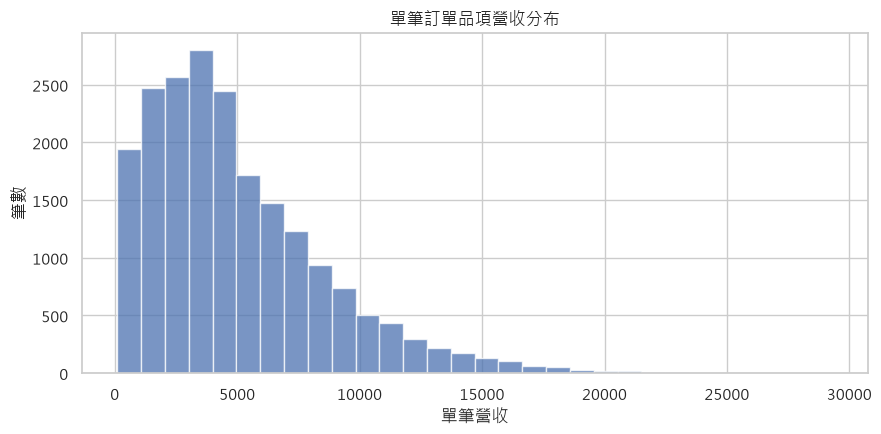

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(facts["line_revenue"], bins=30, edgecolor="white", alpha=0.75)#
ax.set_title("單筆訂單品項營收分布")
ax.set_xlabel("單筆營收")
ax.set_ylabel("筆數")
plt.tight_layout()
plt.show()

**解讀提示**：若大多數資料集中在左側、右側有少數很大的數值，代表分布右偏；此時中位數通常比平均數更能代表典型值。

## 4. 相關係數熱圖：營收與月份

Pearson 相關係數介於 -1 到 1。越接近 1 代表正向線性關係越強，越接近 -1 代表反向線性關係越強，接近 0 則表示線性關係較弱。

,line_revenue,month_num
line_revenue,1.000,-0.005
month_num,-0.005,1.000


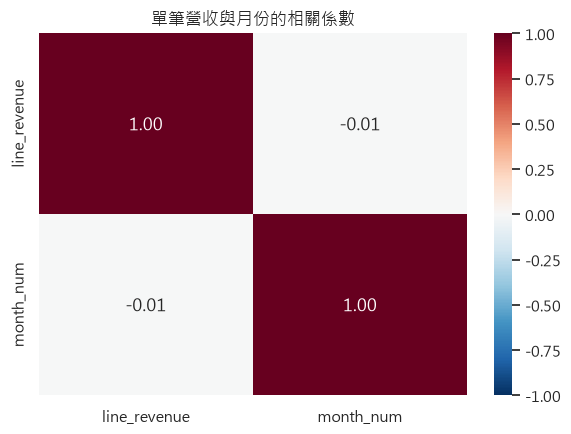

In [5]:
corr_matrix = facts[["line_revenue", "month_num"]].corr()
display(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
    vmin=-1, vmax=1, center=0, ax=ax
)
ax.set_title("單筆營收與月份的相關係數")
plt.tight_layout()
plt.show()

> 注意：相關不等於因果，而且月份數字是循環型資料；若要分析季節性，按月分組或使用時間序列圖通常更合適。

## 5. 長條圖：比較不同客群的營收中位數

因營收容易受到少數高額訂單影響，這裡使用中位數比較各客群的典型單筆營收。

,營收中位數
segment,
vip,4249.00
growth,4175.00
new,4142.05


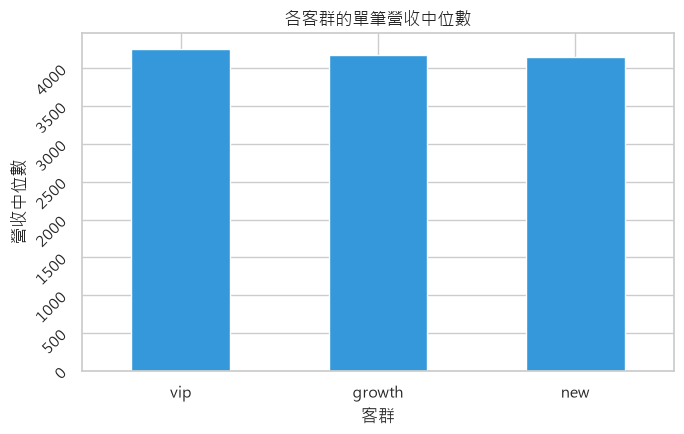

In [6]:
median_rev = (
    facts.groupby("segment")["line_revenue"]
    .median()
    .sort_values(ascending=False)
)
display(median_rev.rename("營收中位數").to_frame().round(2))

fig, ax = plt.subplots(figsize=(7, 4.5))
median_rev.plot(kind="bar", color="#3498db", edgecolor="white", ax=ax)
ax.set_title("各客群的單筆營收中位數")
ax.set_xlabel("客群")
ax.set_ylabel("營收中位數")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=45)
plt.tight_layout()
plt.show()

## 6. 箱型圖練習

箱型圖中央的線是中位數；盒子下緣與上緣分別是 Q1（第 25 百分位）與 Q3（第 75 百分位）。盒子範圍稱為四分位距（IQR）。

Q1=2262.00、Q2（中位數）=4164.30、Q3=6829.50、IQR=4567.50


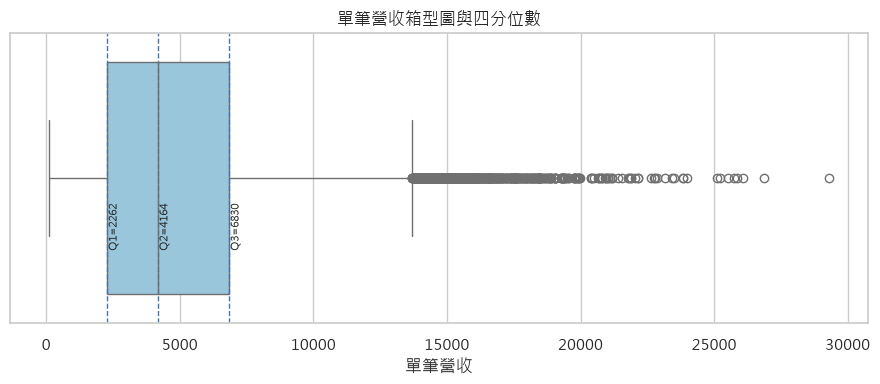

In [7]:
# 計算四分位數，作為箱型圖的數值解讀依據。
q1 = facts["line_revenue"].quantile(0.25)
q2 = facts["line_revenue"].quantile(0.50)
q3 = facts["line_revenue"].quantile(0.75)
print(f"Q1={q1:.2f}、Q2（中位數）={q2:.2f}、Q3={q3:.2f}、IQR={q3-q1:.2f}")

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(x=facts["line_revenue"], ax=ax, color="#8ecae6")

for value, label in [(q1, "Q1"), (q2, "Q2"), (q3, "Q3")]:
    ax.axvline(value, linestyle="--", linewidth=1)# 垂直參考線
    ax.text(value, 0.25, f"{label}={value:.0f}", rotation=90, va="bottom", fontsize=8)

ax.set_title("單筆營收箱型圖與四分位數")
ax.set_xlabel("單筆營收")
plt.tight_layout()
plt.show()

### 6.1 補上客戶的主要流量來源

訂單明細沒有 `traffic_source`，因此先從工作階段資料找出每位客戶最常出現的流量來源（眾數），再合併回訂單明細。

In [8]:
sessions = data["sessions"][["customer_id", "traffic_source"]].dropna()

source_by_customer = (
    sessions.groupby("customer_id")["traffic_source"]
    .agg(lambda values: values.mode().iat[0] if not values.mode().empty else values.iloc[0])
    .rename("traffic_source")
    .reset_index()
)

traffic_facts = (
    order_facts(data)
    .merge(source_by_customer, on="customer_id", how="left")
    .dropna(subset=["traffic_source"])
    .copy()
)

display(traffic_facts[["customer_id", "traffic_source", "line_revenue"]].head())

,customer_id,traffic_source,line_revenue
0,2323,seo,538.65
1,117,seo,4357.70
2,1240,email,1193.40
3,714,email,13175.50
4,2005,seo,3657.50


### 6.2 比較各流量來源的營收分布

並排箱型圖能同時比較各類別的中位數、離散程度與離群值。

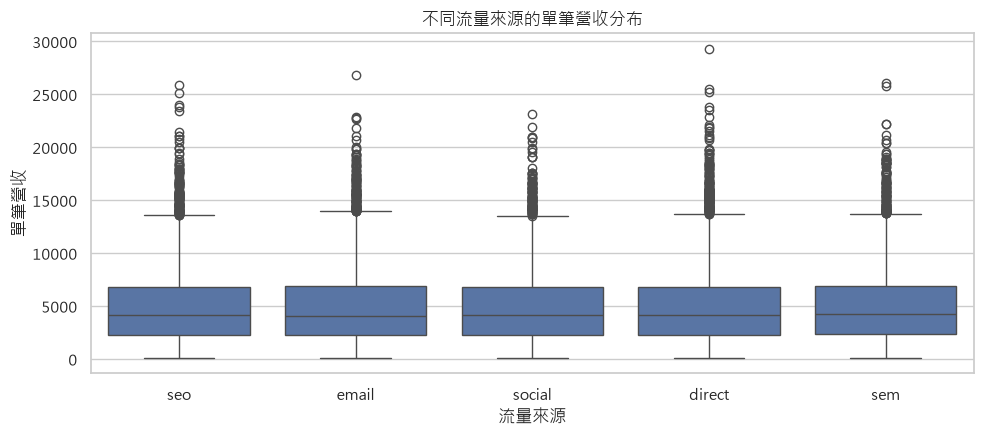

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=traffic_facts, x="traffic_source", y="line_revenue", ax=ax)
ax.set_title("不同流量來源的單筆營收分布")
ax.set_xlabel("流量來源")
ax.set_ylabel("單筆營收")
plt.tight_layout()
plt.show()

### 6.3 在箱型圖標示各組中位數

為避免標示位置與箱型圖類別順序不一致，先明確建立 `source_order`，繪圖與文字標示共用同一順序。

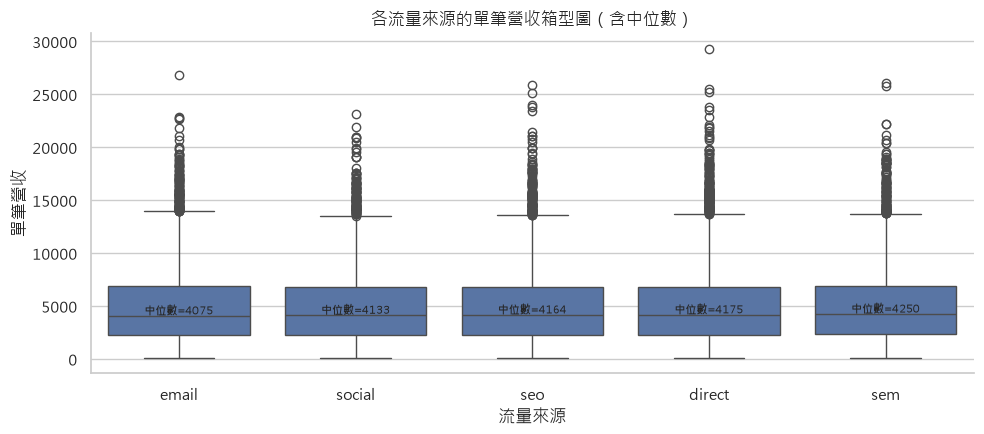

In [10]:
medians = traffic_facts.groupby("traffic_source")["line_revenue"].median().sort_values()
source_order = medians.index.tolist()

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(
    data=traffic_facts, x="traffic_source", y="line_revenue",
    order=source_order, ax=ax
)
sns.despine()

for x_position, source in enumerate(source_order):
    median_value = medians.loc[source]
    ax.text(
        x_position, median_value, f"中位數={median_value:.0f}",
        ha="center", va="bottom", fontsize=8, fontweight="bold"
    )

ax.set_title("各流量來源的單筆營收箱型圖（含中位數）")
ax.set_xlabel("流量來源")
ax.set_ylabel("單筆營收")
plt.tight_layout()
plt.show()

## 7. 練習題

請嘗試回答：哪一個流量來源的單筆營收中位數最高？它的資料筆數是否足夠，讓比較具有代表性？

先自行撰寫，再展開下方參考程式。

In [11]:
# 練習提示：同時彙總每組的資料筆數與中位數。
# TODO：可先遮住下面兩行，自己完成 groupby 與 agg。
exercise_summary = traffic_facts.groupby("traffic_source")["line_revenue"].agg(["count", "median"])
exercise_summary.sort_values("median", ascending=False)

,count,median
traffic_source,,
sem,4125,4250.2
direct,4732,4175.0
seo,3680,4164.3
social,3569,4132.7
email,4307,4075.0


## 常見錯誤與延伸

**常見錯誤**：只看各組中位數就下結論。若某一組樣本很少，結果可能不穩定；應同步檢查 `count`、分布範圍及離群值。

**延伸練習**：
- 將 `segment` 與 `traffic_source` 結合，以分面圖比較不同客群。
- 使用月份分組後畫折線圖，比直接計算 `month_num` 的相關係數更完整地觀察季節性。
- 比較平均數與中位數，說明離群值如何影響兩者。

## 重點整理

- 直方圖用來觀察單一數值變數的整體分布。
- 相關係數描述線性關係，但不能證明因果。
- 中位數較不容易受到極端值影響。
- 箱型圖適合比較多個類別的中位數、IQR 與離群值。
- 合併不同資料表前，必須先確認鍵值與資料粒度。